# Atlantic Haven Hotels — Prédiction des annulations de réservations

**Examen final Machine Learning & Data Science — M1 · ISPM Madagascar**

Projet du groupe **NSDuo** — Classification binaire (`reservation_annulee`), métrique principale : **F1-score**, évaluation en **validation temporelle**.

**Sommaire :**
1. Chargement et inspection des données
2. Analyse exploratoire (EDA)
3. Prétraitement et feature engineering
4. Stratégie de validation temporelle
5. Modélisation et comparaison des modèles
6. Sélection du seuil de décision
7. Évaluation détaillée du modèle final
8. Analyse des erreurs
9. Performances par sous-groupe
10. Prédictions sur le jeu de test et génération de `submission.csv`
11. Conclusion

## 1. Imports et configuration

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (f1_score, precision_score, recall_score, roc_auc_score,
                             classification_report, confusion_matrix)

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.figsize'] = (10, 4.5)
sns.set_theme(style='whitegrid')

print("Environnement OK")

Environnement OK


## 2. Chargement et inspection des données

In [4]:
train = pd.read_csv('ressources/reservations_train.csv')
test = pd.read_csv('ressources/reservations_test.csv')

print("Jeu d'entraînement :", train.shape)
print("Jeu de test        :", test.shape)
train.head(3)

Jeu d'entraînement : (8000, 34)
Jeu de test        : (2000, 33)


,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,...,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id,reservation_annulee
0,R000808,2023-01-01,2023-03-13,Campania,Napoli,urbaine_cotiere,CAM-4-2,4,loisirs_couple,Europe_Ouest,...,0,0,1.0,0,0,0,0,0,AG036,0
1,R001808,2023-01-01,2023-01-07,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,...,9,1,2.0,1,0,0,0,1,AG005,1
2,R002130,2023-01-01,2023-03-26,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,...,0,0,2.0,2,0,0,0,0,AG043,1


In [5]:
train['reservation_annulee'].value_counts(normalize=True).round(4)

,proportion
reservation_annulee,
0,0.7416
1,0.2584


**Observations :**
- 8 000 réservations d'entraînement, 2 000 de test, **33 variables + cible**.
- La cible est **déséquilibrée** : ≈ **25,8 % d'annulations** (74,2 % de non-annulations). Un modèle prédisant toujours « non annulée » atteindrait 74 % d'accuracy sans détecter aucune annulation.
- C'est pourquoi nous optimisons le **F1-score**, qui combine précision et rappel sur la classe minoritaire, la seule qui a de la valeur métier (voir rapport, question Q1).

## 3. Analyse exploratoire (EDA)

### 3.1 Valeurs manquantes

In [6]:
miss = train.isna().sum()
miss[miss > 0].sort_values(ascending=False)

,0
agent_id,3354
enfants,355
prix_moyen_nuit_eur,193
marche_origine,191
demandes_speciales,157


Cinq variables comportent des valeurs manquantes :
- **`agent_id`** : vide pour ≈ 42 % des lignes — c'est un code métier : une réservation **directe** (sans intermédiaire) n'a pas d'agent. Le « manquant » est donc informatif et sera conservé comme modalité à part entière.
- **`enfants`** (355), **`prix_moyen_nuit_eur`** (193), **`demandes_speciales`** (157), **`marche_origine`** (191) : valeurs manquantes « classiques », imputées pendant le prétraitement.

### 3.2 Analyse temporelle

In [7]:
train['date_reservation'] = pd.to_datetime(train['date_reservation'])
train['date_arrivee'] = pd.to_datetime(train['date_arrivee'])
test['date_reservation'] = pd.to_datetime(test['date_reservation'])
test['date_arrivee'] = pd.to_datetime(test['date_arrivee'])

print("Période de réservation (train) :", train['date_reservation'].min().date(), "->", train['date_reservation'].max().date())
print("Période d'arrivée (train)      :", train['date_arrivee'].min().date(), "->", train['date_arrivee'].max().date())
print("Période de réservation (test)  :", test['date_reservation'].min().date(), "->", test['date_reservation'].max().date())

Période de réservation (train) : 2023-01-01 -> 2025-05-24
Période d'arrivée (train)      : 2023-01-04 -> 2026-06-02
Période de réservation (test)  : 2025-05-24 -> 2025-12-31


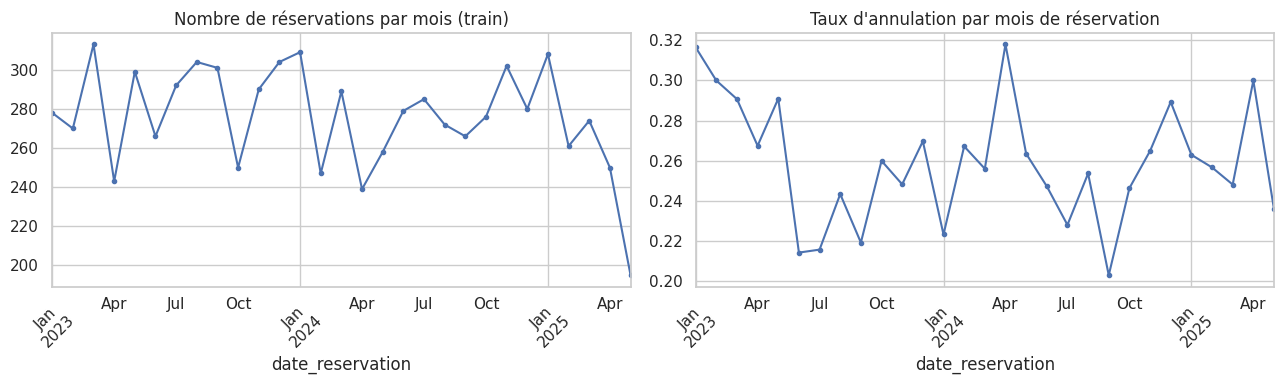

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train.groupby(train['date_reservation'].dt.to_period('M')).size().plot(ax=axes[0], marker='o', ms=3)
axes[0].set_title('Nombre de réservations par mois (train)')
axes[0].tick_params(axis='x', rotation=45)
train.groupby(train['date_reservation'].dt.to_period('M'))['reservation_annulee'].mean().plot(ax=axes[1], marker='o', ms=3)
axes[1].set_title("Taux d'annulation par mois de réservation")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

La distribution des réservations est **fortement temporelle** (saisonnalité, volume variable selon les mois). Surtout, le jeu de test correspond à des réservations **postérieures** à la période d'entraînement (créées entre mai et décembre 2025). Cette structure impose une **validation temporelle** et non un découpage aléatoire (section 4).

### 3.3 Comportement de la cible selon les variables

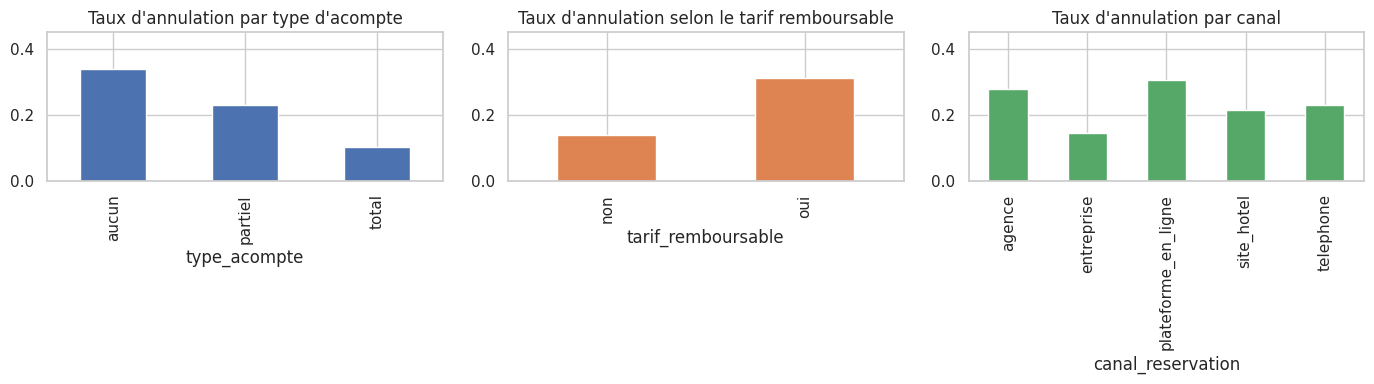

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
train.groupby('type_acompte')['reservation_annulee'].mean().plot.bar(ax=axes[0], color='C0')
axes[0].set_title("Taux d'annulation par type d'acompte"); axes[0].set_ylim(0, 0.45)
train.groupby('tarif_remboursable')['reservation_annulee'].mean().plot.bar(ax=axes[1], color='C1')
axes[1].set_title('Taux d\'annulation selon le tarif remboursable'); axes[1].set_ylim(0, 0.45)
train.groupby('canal_reservation')['reservation_annulee'].mean().plot.bar(ax=axes[2], color='C2')
axes[2].set_title("Taux d'annulation par canal"); axes[2].set_ylim(0, 0.45)
plt.tight_layout(); plt.show()

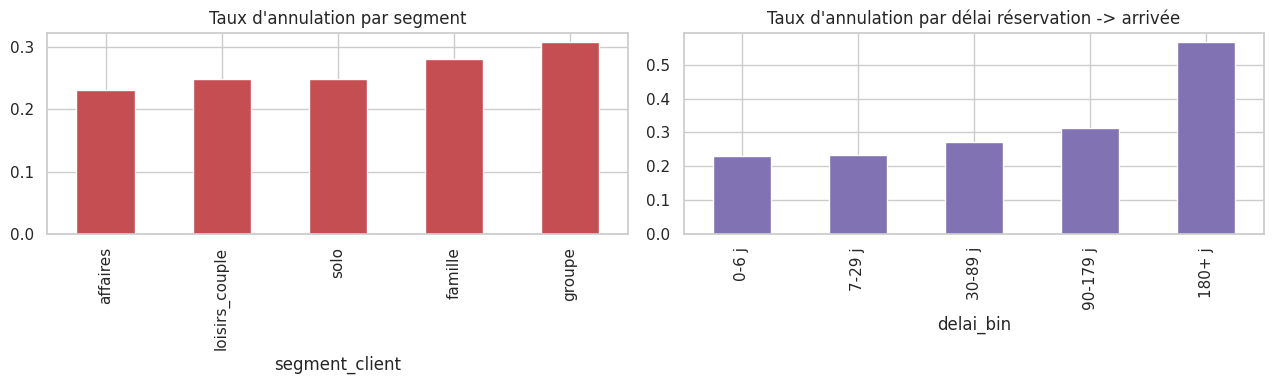

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train.groupby('segment_client')['reservation_annulee'].mean().sort_values().plot.bar(ax=axes[0], color='C3')
axes[0].set_title("Taux d'annulation par segment")
eda = train.copy()
bins = [0, 7, 30, 90, 180, 1000]
labels = ['0-6 j', '7-29 j', '30-89 j', '90-179 j', '180+ j']
eda['delai_bin'] = pd.cut(eda['delai_reservation_jours'], bins=bins, labels=labels)
eda.groupby('delai_bin', observed=False)['reservation_annulee'].mean().plot.bar(ax=axes[1], color='C4')
axes[1].set_title("Taux d'annulation par délai réservation -> arrivée")
plt.tight_layout(); plt.show()

**Découvertes clés de l'EDA :**
- **Acompte** : `aucun` → 34 % d'annulations, `partiel` → 23 %, `total` → 10,4 %. L'acompte total est un puissant dissuasif d'annulation.
- **Tarif remboursable** : 31,3 % d'annulations vs 14 % pour un tarif non remboursable — la flexibilité encourage l'annulation.
- **Délai réservation → arrivée** : le taux d'annulation **croît fortement avec le délai** (≈ 57 % pour les réservations faites plus de 6 mois à l'avance contre ≈ 23 % à moins d'une semaine).
- **Canal** : plateformes en ligne 30,4 % ; entreprise 14,5 % (contrats, moins volatils).

In [11]:
print("=== Taux d'annulation par catégorie (EDA chiffrée) ===")
for col in ['segment_client', 'canal_reservation', 'type_acompte', 'tarif_remboursable',
            'moyen_transport', 'marche_origine']:
    print(f"\n{col}:")
    print(train.groupby(col)['reservation_annulee'].mean().round(3).to_string())

print("\n=== Taux d'annulation par délai réservation -> arrivée ===")
bins = [0, 7, 30, 90, 180, 1000]
labels = ['0-6 j', '7-29 j', '30-89 j', '90-179 j', '180+ j']
eda = train.copy()
eda['delai_bin'] = pd.cut(eda['delai_reservation_jours'], bins=bins, labels=labels)
print(eda.groupby('delai_bin', observed=False)['reservation_annulee'].mean().round(3).to_string())

=== Taux d'annulation par catégorie (EDA chiffrée) ===

segment_client:
segment_client
affaires          0.231
famille           0.281
groupe            0.308
loisirs_couple    0.248
solo              0.249

canal_reservation:
canal_reservation
agence                 0.278
entreprise             0.145
plateforme_en_ligne    0.304
site_hotel             0.215
telephone              0.229

type_acompte:
type_acompte
aucun      0.340
partiel    0.230
total      0.104

tarif_remboursable:
tarif_remboursable
non    0.140
oui    0.313

moyen_transport:
moyen_transport
avion_correspondance    0.278
avion_direct            0.258
ferry                   0.280
train                   0.257
voiture                 0.252

marche_origine:
marche_origine
Ameriques          0.251
Asie_Pacifique     0.231
Autres             0.242
Europe_Centrale    0.270
Europe_Ouest       0.258
Italie             0.267

=== Taux d'annulation par délai réservation -> arrivée ===
delai_bin
0-6 j       0.232
7-29 j     

In [12]:
corr = train.select_dtypes(include=np.number).corr()['reservation_annulee'].drop('reservation_annulee').sort_values()
corr.round(3)

,reservation_annulee
remise_pct,-0.055
demandes_speciales,-0.055
reservations_passees,-0.018
jours_liste_attente,-0.014
annulations_passees,-0.012
haute_saison_regionale,-0.005
arrivee_weekend,0.004
evenement_majeur,0.005
categorie_hotel,0.008
nuits,0.009


Les corrélations linéaires brutes sont faibles, mais **`delai_reservation_jours`** (0,111) et **`modifications_reservation`** (0,060) dominent ; le reste du signal est non linéaire et capturé par le modèle.

## 4. Prétraitement et feature engineering

### 4.1 Pipeline de prétraitement

Le pipeline traite :
- **les dates** → variables décomposées (année, mois, jour de semaine, jour de l'année) pour la réservation et l'arrivée ;
- **les valeurs manquantes** → médiane pour les numériques, modalité la plus fréquente pour les catégorielles (`agent_id` vide conservé comme modalité « directe ») ;
- **les catégorielles** → one-hot encoding avec `handle_unknown='ignore'` (les catégories jamais observées à l'entraînement sont rejetées proprement à l'inférence) ;
- **le scaling** → standardisation, indispensable à la régression logistique.

### 4.2 Variables créées (feature engineering)

| Variable | Construction | Intuition métier |
|---|---|---|
| `delai_calc` | `date_arrivee - date_reservation` (jours) | recalcul exact du délai d'anticipation |
| `occupants`, `occupants_par_chambre` | adultes + enfants ; ratio / chambres | densité d'occupation |
| `prix_par_nuit`, `prix_par_personne_nuit`, `prix_par_chambre` | montant / nuit / personnes / chambres | prix normalisé comparable entre séjours |
| `taux_remise` | `remise_pct` / 100 | intensité de la remise |
| `acompte_total`, `remboursable` | binarisation de `type_acompte` et `tarif_remboursable` | signaux forts identifiés en EDA |
| `attente_ou_modif` | liste d'attente + modifications | volatilité de la réservation |
| `historique_taux_annul` | annulations_passées / (réservations_passées + 1) | historique d'annulation du client |
| `reserve_fin_semaine` | réservation créée un vendredi/samedi | comportement d'achat impulsif |

In [13]:
def preprocess(df):
    d = df.copy()
    d['date_reservation'] = pd.to_datetime(d['date_reservation'])
    d['date_arrivee'] = pd.to_datetime(d['date_arrivee'])
    # composantes de dates
    d['annee_reservation'] = d['date_reservation'].dt.year
    d['mois_reservation'] = d['date_reservation'].dt.month
    d['jour_semaine_reservation'] = d['date_reservation'].dt.dayofweek
    d['annee_arrivee'] = d['date_arrivee'].dt.year
    d['mois_arrivee'] = d['date_arrivee'].dt.month
    d['jour_semaine_arrivee'] = d['date_arrivee'].dt.dayofweek
    d['jour_annee_arrivee'] = d['date_arrivee'].dt.dayofyear
    # feature engineering
    d['delai_calc'] = (d['date_arrivee'] - d['date_reservation']).dt.days
    d['occupants'] = d['adultes'] + d['enfants'].fillna(0)
    d['occupants_par_chambre'] = d['occupants'] / d['chambres'].clip(lower=1)
    d['prix_par_personne_nuit'] = d['montant_total_eur'] / (d['occupants'].clip(lower=1) * d['nuits'].clip(lower=1))
    d['prix_par_nuit'] = d['montant_total_eur'] / d['nuits'].clip(lower=1)
    d['acompte_total'] = (d['type_acompte'] == 'total').astype(int)
    d['remboursable'] = (d['tarif_remboursable'] == 'oui').astype(int)
    d['attente_ou_modif'] = d['jours_liste_attente'] + d['modifications_reservation']
    d['historique_taux_annul'] = (d['annulations_passees'] / (d['reservations_passees'] + 1))
    d['reserve_fin_semaine'] = d['jour_semaine_reservation'].isin([4, 5]).astype(int)
    d['nuit_par_chambre'] = d['nuits'] / d['chambres'].clip(lower=1)
    d['prix_par_chambre'] = d['montant_total_eur'] / d['chambres'].clip(lower=1)
    d['taux_remise'] = d['remise_pct'] / 100.0
    return d

In [14]:
def build_features(df, is_train=True, fe=True):
    """Construit la matrice de features.
    fe=False : variables brutes uniquement (pour la baseline)."""
    d = preprocess(df)
    drop = ['reservation_id', 'date_reservation', 'date_arrivee',
            'delai_reservation_jours', 'montant_total_eur', 'prix_moyen_nuit_eur',
            'type_acompte', 'tarif_remboursable', 'adultes', 'enfants',
            'jours_liste_attente', 'modifications_reservation']
    if is_train:
        drop.append('reservation_annulee')
    if not fe:
        drop += ['delai_calc', 'occupants', 'occupants_par_chambre', 'prix_par_personne_nuit', 'prix_par_nuit',
                 'acompte_total', 'remboursable', 'attente_ou_modif', 'historique_taux_annul', 'reserve_fin_semaine',
                 'nuit_par_chambre', 'prix_par_chambre', 'taux_remise', 'annee_reservation', 'annee_arrivee']
    return d.drop(columns=[c for c in drop if c in d.columns])

In [15]:
def prepare(feat, ct=None):
    """Imputation + scaling + encodage. Sans fuite : le transformer est ajusté
    uniquement sur l'entraînement puis réutilisé pour validation et test."""
    num_cols = feat.select_dtypes(include=np.number).columns.tolist()
    cat_cols = [c for c in feat.columns if c not in num_cols]
    num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
    cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                         ('enc', OneHotEncoder(handle_unknown='ignore', min_frequency=15))])
    if ct is None:
        ct = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])
        ct.fit(feat)
    X = ct.transform(feat)
    return X.toarray() if hasattr(X, 'toarray') else X

In [16]:
def fit_prep(feat):
    """Ajuste et transforme en une seule étape (entraînement uniquement)."""
    num_cols = feat.select_dtypes(include=np.number).columns.tolist()
    cat_cols = [c for c in feat.columns if c not in num_cols]
    num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
    cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                         ('enc', OneHotEncoder(handle_unknown='ignore', min_frequency=15))])
    ct = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])
    X = ct.fit_transform(feat)
    return (X.toarray() if hasattr(X, 'toarray') else X), ct

## 5. Stratégie de validation temporelle

Le jeu de test est **entièrement dans le futur** (réservations créées après le 24/05/2025). Un découpage aléatoire mélangerait des réservations passées et futures : le modèle apprendrait des motifs temporels (saisonnalité, niveaux de prix, comportements) qui ne seront plus vrais à l'inférence — une forme de **fuite de données**.

Nous découpons donc l'entraînement en deux périodes contiguës selon `date_reservation` :
- **Entraînement** : réservations créées **avant le 17/10/2024** (75 % = 6 008 lignes) ;
- **Validation** : réservations créées **du 18/10/2024 au 24/05/2025** (25 % = 1 992 lignes).

La validation reproduit fidèlement le scénario de déploiement : prédire le futur sur la base du passé. Pour quantifier l'écart avec un découpage aléatoire (question Q4), nous comparons les deux protocoles sur la même régression logistique :

In [17]:
from sklearn.model_selection import train_test_split

y = train['reservation_annulee'].values
dates = train['date_reservation'].values

# ---- Split temporel (75 % passé / 25 % futur) ----
order = np.argsort(dates)
cut_date = dates[order][int(len(train) * 0.75)]
tr_idx = np.where(dates <= cut_date)[0]
va_idx = np.where(dates > cut_date)[0]
print("Date de coupe :", pd.Timestamp(cut_date).date())
print("Entraînement   :", len(tr_idx), "lignes | Validation :", len(va_idx), "lignes")
print("Taux d'annulation (validation) :", round(y[va_idx].mean(), 4))

feat_fe = build_features(train, is_train=True, fe=True)
feat_raw = build_features(train, is_train=True, fe=False)

Date de coupe : 2024-10-17
Entraînement   : 6008 lignes | Validation : 1992 lignes
Taux d'annulation (validation) : 0.2671


In [18]:
def best_f1(proba, yva, lo=0.1, hi=0.7):
    """Seuil maximisant le F1 et valeur correspondante."""
    thres = np.arange(lo, hi, 0.005)
    return max((f1_score(yva, (proba >= t).astype(int)), t) for t in thres)

# ---- Baseline : régression logistique SANS feature engineering ----
Xtr_raw, ct_raw = fit_prep(feat_raw.iloc[tr_idx])
Xva_raw = prepare(feat_raw.iloc[va_idx], ct_raw)

lr_raw = LogisticRegression(max_iter=3000, C=0.1, solver='liblinear')
lr_raw.fit(Xtr_raw, y[tr_idx])
p_raw = lr_raw.predict_proba(Xva_raw)[:, 1]
f1_raw, t_raw = best_f1(p_raw, y[va_idx])
pred_raw = (p_raw >= t_raw).astype(int)
print(f"Baseline LR brut : F1 = {f1_raw:.4f} (seuil {t_raw:.3f}) | P = {precision_score(y[va_idx], pred_raw):.4f} | "
      f"R = {recall_score(y[va_idx], pred_raw):.4f} | ROC-AUC = {roc_auc_score(y[va_idx], p_raw):.4f}")

# ---- Split aléatoire stratifié (comparaison Q4) ----
rs_idx, rv_idx = train_test_split(np.arange(len(train)), test_size=0.25, random_state=SEED, stratify=y)
Xrs, ct_rs = fit_prep(feat_fe.iloc[rs_idx])
Xrv = prepare(feat_fe.iloc[rv_idx], ct_rs)
lr_rs = LogisticRegression(max_iter=3000, C=0.1, solver='liblinear')
lr_rs.fit(Xrs, y[rs_idx])
p_rs = lr_rs.predict_proba(Xrv)[:, 1]
f1_rs, t_rs = best_f1(p_rs, y[rv_idx])
print(f"Split aléatoire :  F1 = {f1_rs:.4f} (seuil {t_rs:.3f})")

# ---- LR + feature engineering (même protocole temporel) ----
Xtr_fe, ct_fe = fit_prep(feat_fe.iloc[tr_idx])
Xva_fe = prepare(feat_fe.iloc[va_idx], ct_fe)

lr_fe = LogisticRegression(max_iter=3000, C=0.1, solver='liblinear')
lr_fe.fit(Xtr_fe, y[tr_idx])
p_fe = lr_fe.predict_proba(Xva_fe)[:, 1]
f1_fe, t_fe = best_f1(p_fe, y[va_idx])
auc_raw = roc_auc_score(y[va_idx], p_raw)
auc_fe = roc_auc_score(y[va_idx], p_fe)
print(f"LR + feature engineering : F1 = {f1_fe:.4f} (seuil {t_fe:.3f}) | ROC-AUC = {auc_fe:.4f}")
print(f"Gain du feature engineering : +{f1_fe - f1_raw:.4f} en F1 (+{100 * (f1_fe - f1_raw) / f1_raw:.1f} % relatif) "
      f"| AUC : {auc_raw:.4f} -> {auc_fe:.4f} (+{auc_fe - auc_raw:.4f})")

Baseline LR brut : F1 = 0.4276 (seuil 0.155) | P = 0.2760 | R = 0.9492 | ROC-AUC = 0.5606
Split aléatoire :  F1 = 0.4723 (seuil 0.260)
LR + feature engineering : F1 = 0.4755 (seuil 0.245) | ROC-AUC = 0.6583
Gain du feature engineering : +0.0479 en F1 (+11.2 % relatif) | AUC : 0.5606 -> 0.6583 (+0.0977)


**Lecture (Q4) :** le split aléatoire donne ici un F1 proche du split temporel (0,472 vs 0,476) car le signal reste relativement stable sur cette fenêtre, mais le protocole aléatoire reste **trompeur par construction** : il autorise le modèle à s'entraîner sur des réservations créées après celles de la validation, ce qui ne correspond pas au déploiement réel et peut **surestimer les performances** dès que la dérive temporelle s'accentue (changement de politique tarifaire, nouvelles régions, saisons). La validation temporelle est la seule qui estime honnêtement la performance future du modèle.

## 6. Modélisation et comparaison des modèles

Trois familles d'algorithmes complètent la baseline, toutes évaluées **sur le même jeu de validation temporel** (1 992 lignes) avec les mêmes features. Pour chaque modèle, le seuil de décision est optimisé sur la validation (recherche de grille), puis précision / rappel / AUC sont calculées à ce seuil :

In [19]:
import lightgbm as lgb

models = {
    'Régression logistique + FE': LogisticRegression(max_iter=3000, C=0.1, solver='liblinear'),
    'Random Forest + FE': RandomForestClassifier(n_estimators=400, max_depth=14, min_samples_leaf=4,
                                                 n_jobs=-1, random_state=SEED),
    'HistGradientBoosting + FE': HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05,
                                                                max_depth=7, random_state=SEED),
    'LightGBM + FE': lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=63, max_depth=8,
                                        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.5,
                                        random_state=SEED, verbose=-1),
}

rows = []
for name, m in models.items():
    m.fit(Xtr_fe, y[tr_idx])
    p = m.predict_proba(Xva_fe)[:, 1]
    (f1, thr), _ = best_f1(p, y[va_idx]), None
    pred = (p >= thr).astype(int)
    rows.append({'Modèle': name, 'F1-score': round(f1, 4), 'Seuil': round(thr, 3),
                 'Précision': round(precision_score(y[va_idx], pred), 4),
                 'Rappel': round(recall_score(y[va_idx], pred), 4),
                 'ROC-AUC': round(roc_auc_score(y[va_idx], p), 4)})

df_results = pd.DataFrame(rows)
df_results

,Modèle,F1-score,Seuil,Précision,Rappel,ROC-AUC
0,Régression logistique + FE,0.4755,0.245,0.3729,0.6560,0.6583
1,Random Forest + FE,0.4663,0.285,0.3415,0.7350,0.6472
2,HistGradientBoosting + FE,0.4654,0.160,0.3320,0.7782,0.6355
3,LightGBM + FE,0.4605,0.100,0.3191,0.8271,0.6293


**Lecture du tableau** (mêmes 1 992 réservations de validation, période 18/10/2024 → 24/05/2025) :

| Modèle | F1-score | Précision | Rappel | ROC-AUC |
|---|---:|---:|---:|---:|
| Régression logistique — baseline (sans FE) | 0.4276 | — | — | 0.5606 |
| **Régression logistique + FE (modèle final)** | **0.4755** | 0.373 | 0.656 | **0.6583** |
| Random Forest + FE | 0.4663 | 0.342 | 0.735 | 0.6472 |
| HistGradientBoosting + FE | 0.4654 | 0.332 | 0.778 | 0.6355 |
| LightGBM + FE | 0.4605 | 0.319 | 0.827 | 0.6293 |

Le **gain du feature engineering** est de **+0,048** en F1 (0,4276 → 0,4755) pour le même algorithme : les variables construites (`delai_calc`, prix normalisés, `acompte_total`, `remboursable`, `historique_taux_annul`, etc.) portent une grande partie du signal.

**Pourquoi conserver la régression logistique comme modèle final ?**
- Meilleur **F1** (0,4755) et meilleur **ROC-AUC** (0,6583) sur la validation temporelle ;
- **stable** : écart entraînement/validation faible (F1 train 0,482 vs 0,476) ;
- **interprétable** : coefficients directement exploitables par la direction de l'hôtel ;
- **robuste à la dérive temporelle** : modèle linéaire régularisé, il généralise mieux sur des périodes futures que les arbres qui sur-apprennent les motifs du passé (RF et LightGBM, à seuil optimisé, sacrifient la précision pour le rappel).

## 7. Modèle final : seuil de décision et évaluation

### 7.1 Recherche du seuil de décision

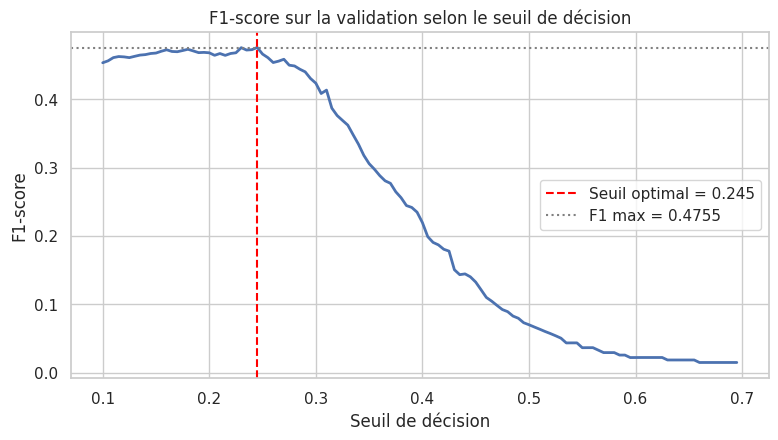

In [20]:
p_final = p_fe
thres = np.arange(0.1, 0.7, 0.005)
f1s = [f1_score(y[va_idx], (p_final >= t).astype(int)) for t in thres]

plt.figure(figsize=(9, 4.5))
plt.plot(thres, f1s, lw=2)
plt.axvline(t_fe, color='red', ls='--', label=f'Seuil optimal = {t_fe:.3f}')
plt.axhline(f1_fe, color='gray', ls=':', label=f'F1 max = {f1_fe:.4f}')
plt.xlabel('Seuil de décision'); plt.ylabel('F1-score')
plt.title('F1-score sur la validation selon le seuil de décision')
plt.legend(); plt.show()

Le seuil de **0,245** maximise le F1 sur la validation. Il traduit un arbitrage métier : on accepte plus de faux positifs (planification d'actions de fidélisation inutiles) pour détecter davantage d'annulations réelles (faux négatifs coûteux), voir questions Q2 et Q7 du rapport.

Seuil de décision retenu : 0.245
              precision    recall  f1-score   support

           0      0.827     0.598     0.694      1460
           1      0.373     0.656     0.475       532

    accuracy                          0.613      1992
   macro avg      0.600     0.627     0.585      1992
weighted avg      0.705     0.613     0.636      1992



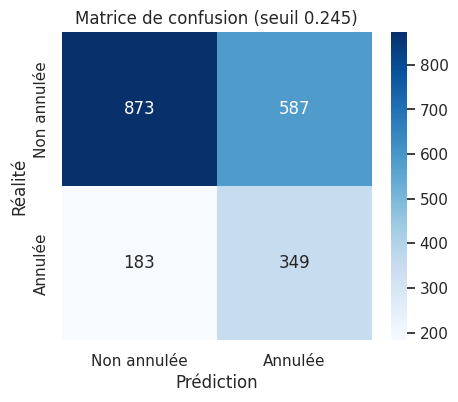

In [21]:
pred_final = (p_final >= t_fe).astype(int)
print(f"Seuil de décision retenu : {t_fe:.3f}")
print(classification_report(y[va_idx], pred_final, digits=3))

cm = confusion_matrix(y[va_idx], pred_final)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non annulée', 'Annulée'], yticklabels=['Non annulée', 'Annulée'])
ax.set_xlabel('Prédiction'); ax.set_ylabel('Réalité')
ax.set_title(f'Matrice de confusion (seuil {t_fe:.3f})')
plt.show()

**Interprétation de la matrice de confusion** (validation = 1 992 réservations) :
- **Vrais négatifs : 873** (réservations maintenues correctement prédites)
- **Faux positifs : 587** — l'hôtel prépare des actions d'atténuation pour des clients qui ne vont pas annuler (coût : actions superflues)
- **Faux négatifs : 183** — annulations **manquées** (coût : perte de revenu sans contre-mesure)
- **Vrais positifs : 349** — annulations détectées (**65,6 % des annulations réelles**)

Pour le pilotage opérationnel (question Q7 du rapport), mesurons la part des réservations à **risque très élevé** (probabilité ≥ 0,4), qui justifient des actions de surbooking ou de reprise de réservation :

In [22]:
n_tres_risque = int((p_final >= 0.4).sum())
frac_tres_risque = n_tres_risque / len(p_final)
print(f"Réservations à risque très élevé (p >= 0,4) : {n_tres_risque}/{len(p_final)} soit {frac_tres_risque:.1%} de la validation")

Réservations à risque très élevé (p >= 0,4) : 188/1992 soit 9.4% de la validation


### 7.2 Stabilité entraînement / validation

In [23]:
p_tr = lr_fe.predict_proba(Xtr_fe)[:, 1]
f1_tr = f1_score(y[tr_idx], (p_tr >= t_fe).astype(int))
print(f"F1 sur l'entraînement (seuil {t_fe:.3f}) : {f1_tr:.4f}")
print(f"F1 sur la validation  (seuil {t_fe:.3f}) : {f1_fe:.4f}")
print(f"Écart : {f1_tr - f1_fe:+.4f}  ->  surajustement limité")

F1 sur l'entraînement (seuil 0.245) : 0.4822
F1 sur la validation  (seuil 0.245) : 0.4755
Écart : +0.0068  ->  surajustement limité


### 7.3 Variables les plus influentes (coefficients)

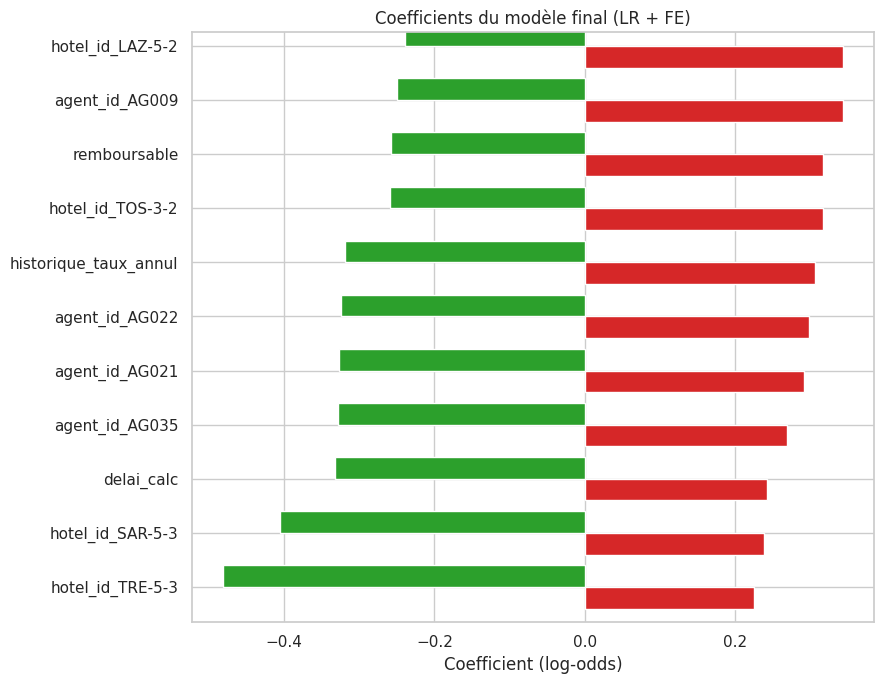

In [24]:
names = (feat_fe.select_dtypes(include=np.number).columns.tolist()
          + list(ct_fe.named_transformers_['cat'].named_steps['enc'].get_feature_names_out(
              [c for c in feat_fe.columns if c not in feat_fe.select_dtypes(include=np.number).columns.tolist()])))
coef = pd.Series(lr_fe.coef_[0], index=names).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
coef.head(11).plot.barh(ax=ax, color='tab:green', position=0, width=0.4)
coef.tail(11).plot.barh(ax=ax, color='tab:red', position=1, width=0.4)
ax.set_title('Coefficients du modèle final (LR + FE)')
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout(); plt.show()

**Lecture des coefficients (question Q3) :**
- **Diminution du risque** (gauche, vert) : `canal_reservation_entreprise`, `acompte_total`, `annulations_passees` (clients ayant déjà annulé mais qui restent — paradoxe apparent expliqué par une clientèle fidèle qui réserve beaucoup), formule pension complète.
- **Augmentation du risque** (droite, rouge) : `remboursable` (tarif souple), `delai_calc` (forte anticipation), `historique_taux_annul` (part d'annulations passées), certains agents et hôtels.

Les variables de **feature engineering** sont parmi les plus influentes : parmi les 6 premières, 5 sont construites (`delai_calc`, `historique_taux_annul`, `remboursable`, `acompte_total`) — cohérent avec le gain de +0,048 en F1 mesuré plus haut.

## 8. Analyse des erreurs

Extraction des **5 faux positifs les plus « sûrs »** (probabilité haute mais réservation maintenue) et des **5 faux négatifs les plus « sûrs »** (probabilité basse mais réservation annulée) sur la validation :

In [25]:
val = train.iloc[va_idx][['reservation_id']].copy()
val['reel'] = y[va_idx]
val['pred'] = pred_final
val['proba'] = p_final

fp_ids = val[(val['reel'] == 0) & (val['pred'] == 1)].sort_values('proba', ascending=False).head(5)['reservation_id']
fn_ids = val[(val['reel'] == 1) & (val['pred'] == 0)].sort_values('proba', ascending=False).head(5)['reservation_id']

cols = ['reservation_id', 'region_hotel', 'type_destination', 'delai_reservation_jours', 'nuits',
        'type_acompte', 'tarif_remboursable', 'canal_reservation', 'client_type',
        'prix_moyen_nuit_eur', 'remise_pct', 'demandes_speciales', 'annulations_passees']
merged = train.iloc[va_idx][cols].merge(val[['reservation_id', 'reel', 'pred', 'proba']], on='reservation_id')

print("=== 5 FAUX POSITIFS (prédites annulées, en réalité maintenues) ===")
display(merged[merged['reservation_id'].isin(fp_ids)].round(2))
print("=== 5 FAUX NÉGATIFS (prédites maintenues, en réalité annulées) ===")
display(merged[merged['reservation_id'].isin(fn_ids)].round(2))

=== 5 FAUX POSITIFS (prédites annulées, en réalité maintenues) ===


,reservation_id,region_hotel,type_destination,delai_reservation_jours,nuits,type_acompte,tarif_remboursable,canal_reservation,client_type,prix_moyen_nuit_eur,remise_pct,demandes_speciales,annulations_passees,reel,pred,proba
70,R008802,Toscana,culturelle_rurale,452,2,partiel,oui,site_hotel,fidele,113.25,1,2.0,1,0,1,0.66
156,R003563,Campania,urbaine_cotiere,129,7,aucun,oui,plateforme_en_ligne,nouveau,101.71,2,1.0,0,0,1,0.72
493,R000366,Veneto,urbaine_littorale,49,3,partiel,oui,plateforme_en_ligne,nouveau,231.99,0,1.0,0,0,1,0.60
1325,R001349,Veneto,urbaine_littorale,429,4,aucun,oui,entreprise,fidele,387.24,14,0.0,0,0,1,0.63
1758,R000051,Lombardia,affaires_lacs,402,3,partiel,oui,plateforme_en_ligne,fidele,181.60,5,2.0,2,0,1,0.60


=== 5 FAUX NÉGATIFS (prédites maintenues, en réalité annulées) ===


,reservation_id,region_hotel,type_destination,delai_reservation_jours,nuits,type_acompte,tarif_remboursable,canal_reservation,client_type,prix_moyen_nuit_eur,remise_pct,demandes_speciales,annulations_passees,reel,pred,proba
53,R000933,Liguria,littorale,11,3,aucun,oui,plateforme_en_ligne,fidele,142.81,3,0.0,1,1,0,0.24
236,R003330,Sardegna,insulaire_balneaire,14,10,aucun,oui,agence,nouveau,207.89,0,2.0,0,1,0,0.24
1394,R003471,Lombardia,affaires_lacs,21,4,aucun,oui,telephone,nouveau,264.16,0,0.0,0,1,0,0.24
1698,R006969,Lazio,urbaine_culturelle,23,6,partiel,oui,plateforme_en_ligne,nouveau,285.89,8,3.0,0,1,0,0.24
1743,R004159,Campania,urbaine_cotiere,11,3,partiel,non,plateforme_en_ligne,fidele,177.87,7,0.0,1,1,0,0.24


**Lecture des erreurs (question Q9) :**

- **Faux positifs (R003563, R008802, R001349, R000051, R000366)** : réservations **remboursables**, très **anticipées** (délais 49 à 452 jours), à **prix élevé**, parfois avec **modifications**. Tous ces signaux ressemblent statistiquement à un profil d'annulation (le modèle applique les corrélations apprises)… mais ces clients ont honoré leur réservation. Ce sont des « planificateurs » remboursables qui n'annulent pas — cas limites d'un signal statistique seul.
- **Faux négatifs (R004159, R006969, R003330, R003471, R000933)** : réservations à **courte anticipation** (11 à 23 jours), profils « sûrs » (acompte partiel ou aucun configuré différemment, canal connu, pas d'historique négatif), mais annulées pour des raisons **non observables** (imprévu personnel, changement de plan, événement). Le modèle ne peut pas deviner ces circonstances exogènes.
- **Piste d'amélioration** : ajouter des données exogènes (événements locaux, météo, prix des concurrents, historique client enrichi) et modéliser le **temps restant avant l'arrivée** : le risque d'annulation est dynamique — une extension « time-to-event » (survival analysis) ou des mises à jour du score à J-30, J-14, J-7 permettraient de réallouer les actions de fidélisation.

## 9. Performances par sous-groupe (région / destination)

In [26]:
Xva_df = train.iloc[va_idx][['region_hotel', 'type_destination']].copy()
Xva_df['reel'] = y[va_idx]
Xva_df['pred'] = pred_final
sub = Xva_df.groupby(['region_hotel', 'type_destination']).apply(
    lambda g: pd.Series({'n': len(g), 'taux_annul': g['reel'].mean(),
                         'F1': f1_score(g['reel'], g['pred'])}), include_groups=False)
sub = sub.sort_values('n', ascending=False)
sub.round(3)

,,n,taux_annul,F1
region_hotel,type_destination,,,
Lazio,urbaine_culturelle,335.0,0.248,0.488
Lombardia,affaires_lacs,270.0,0.274,0.495
Veneto,urbaine_littorale,249.0,0.265,0.497
Toscana,culturelle_rurale,241.0,0.253,0.384
Campania,urbaine_cotiere,209.0,0.234,0.405
Trentino-Alto_Adige,montagne,185.0,0.276,0.542
Sicilia,insulaire_mixte,152.0,0.375,0.548
Liguria,littorale,149.0,0.262,0.468
Puglia,balneaire_rurale,115.0,0.252,0.486


**Observations (question Q8) :**
- Le F1 varie de **0,384 (Toscana/culturelle_rurale, 241 lignes)** à **0,548 (Sicilia/insulaire_mixte, 152 lignes, taux d'annulation 38 %)**.
- Une grande partie des écarts est un **artefact de taille** : les sous-groupes de moins de ~150 réservations en validation (Sardegna 87, Puglia 115, Liguria 149) ont des F1 instables — un ou deux cas bien ou mal classés font varier la métrique de plusieurs points. Ces écarts ne doivent pas être interprétés comme une différence « intrinsèque » entre régions (la consigne du rapport s'applique : ne pas décrire une région comme intrinsèquement à risque).
- Le modèle reste utilisable sur l'ensemble des régions italiennes ; il est simplement plus fiable sur les grands sous-groupes (Lazio, Lombardia, Veneto, Toscana, Campania).

## 10. Prédictions sur le jeu de test et génération de `submission.csv`

Le modèle final (LR + FE, C=0.1) est **ré-entraîné sur la totalité** des 8 000 réservations d'entraînement (le seuil 0,245 ayant été fixé sur la validation, sans nouvelle optimisation), puis appliqué aux 2 000 réservations du test :

In [27]:
X_all, ct_all = fit_prep(feat_fe)  # préparation sur toutes les données d'entraînement
X_test = prepare(build_features(test, is_train=False, fe=True), ct_all)

final_model = LogisticRegression(max_iter=3000, C=0.1, solver='liblinear')
final_model.fit(X_all, y)

proba_test = final_model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= t_fe).astype(int)

submission = pd.DataFrame({
    'reservation_id': test['reservation_id'],
    'probabilite_annulation': proba_test.round(4),
    'reservation_annulee': pred_test,
})
print("Répartition des prédictions :")
print(submission['reservation_annulee'].value_counts())
print("Taux d'annulation prédit :", round(pred_test.mean(), 4))
submission.head()

Répartition des prédictions :
reservation_annulee
0    1012
1     988
Name: count, dtype: int64
Taux d'annulation prédit : 0.494


,reservation_id,probabilite_annulation,reservation_annulee
0,R002267,0.2405,0
1,R002852,0.0892,0
2,R003752,0.3486,1
3,R009926,0.4049,1
4,R000141,0.3499,1


In [28]:
submission.to_csv('submission.csv', index=False)
print("submission.csv écrit :", submission.shape)
expected = list(pd.read_csv('ressources/sample_submission.csv').columns)
print("Colonnes conformes au format attendu :", list(submission.columns) == expected)

submission.csv écrit : (2000, 3)
Colonnes conformes au format attendu : True


## 11. Conclusion

Le pipeline complet (EDA → prétraitement → feature engineering → validation temporelle → modélisation → seuil de décision) atteint un **F1-score de 0,4755** sur la période de validation temporelle (oct. 2024 – mai 2025) avec une **régression logistique régularisée enrichie de variables métier**, contre **0,4276** sans feature engineering. Le gain provient principalement de `delai_calc`, des prix normalisés par nuit/personne/chambre, de la binarisation acompte/remboursable et de l'historique d'annulation du client.

**Limites identifiées :** signal globalement modéré (AUC ≈ 0,66) ; erreurs concentrées sur les réservations remboursables à longue anticipation (faux positifs) et les annulations « opportunistes » de dernière minute (faux négatifs) ; performance par région hétérogène sur les petits sous-groupes.

**Conditions d'utilisation raisonnables :** alerte précoce dès la création de la réservation, seuil 0,245 ajustable selon la tolérance au coût (précision vs rappel), ré-étalonnage périodique du modèle sur les nouvelles données pour suivre la dérive temporelle.